<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/tarefa_aula4_australia__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Descrição do Dataset — Rain in Australia (weatherAUS)

**Fonte:** Kaggle — "Rain in Australia" (jsphyg/weather-dataset-rattle-package),
dados originais do Bureau of Meteorology (BOM) da Austrália.

**Contexto:** ~10 anos de observações meteorológicas diárias coletadas em
diversas estações espalhadas pela Austrália.

**Tamanho:** 145.460 linhas x 23 colunas

**Variável alvo:** `RainTomorrow` (Yes/No) — indica se choveu no dia seguinte.


**Principais colunas:**
- `Date` — data da observação
- `Location` — cidade/estação meteorológica
- `MinTemp` / `MaxTemp` — temperatura mínima/máxima do dia (°C)
- `Rainfall` — quantidade de chuva no dia (mm)
- `Evaporation` — evaporação (mm)
- `Sunshine` — horas de sol no dia
- `WindGustDir` / `WindGustSpeed` — direção/velocidade da rajada de vento mais forte
- `WindDir9am` / `WindDir3pm` — direção do vento às 9h/15h
- `WindSpeed9am` / `WindSpeed3pm` — velocidade do vento às 9h/15h
- `Humidity9am` / `Humidity3pm` — umidade relativa às 9h/15h (%)
- `Pressure9am` / `Pressure3pm` — pressão atmosférica às 9h/15h (hPa)
- `Cloud9am` / `Cloud3pm` — cobertura de nuvens às 9h/15h (oktas, 0-8)
- `Temp9am` / `Temp3pm` — temperatura às 9h/15h (°C)
- `RainToday` — choveu hoje? (Yes/No)
- `RainTomorrow` — choveu amanhã? (Yes/No) — **alvo**

## **Importando as Bibliotecas/ Dados**

In [67]:
import pandas as pd

In [68]:
df = pd.read_csv('/content/weatherAUS.csv')

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# I. Análise Exploratória Geral

1. Quantas linhas e colunas tem o dataset?
2. Qual a porcentagem de nulos?
3. Qual o tipo de cada coluna?
4. Existem colunas que podemos remover?
5. Os tipos de coluna estão adequados para os tipos de variáveis?
6. Temos dados duplicados?
7. Qual a média, desvio padrão e amplitude das colunas numéricas?

## 1. Quantas linhas e colunas tem o dataset?

In [69]:
#1
df.shape

(145460, 23)

## 2. Qual a porcentagem de nulos?

In [70]:
#2
df_nulos = (df.isnull().sum()/df.shape[0]).sort_values(ascending=False)*100
df_nulos

,0
Sunshine,48.009762
Evaporation,43.166506
Cloud3pm,40.807095
Cloud9am,38.421559
Pressure9am,10.356799
Pressure3pm,10.331363
WindDir9am,7.263853
WindGustDir,7.098859
WindGustSpeed,7.055548
Humidity3pm,3.098446


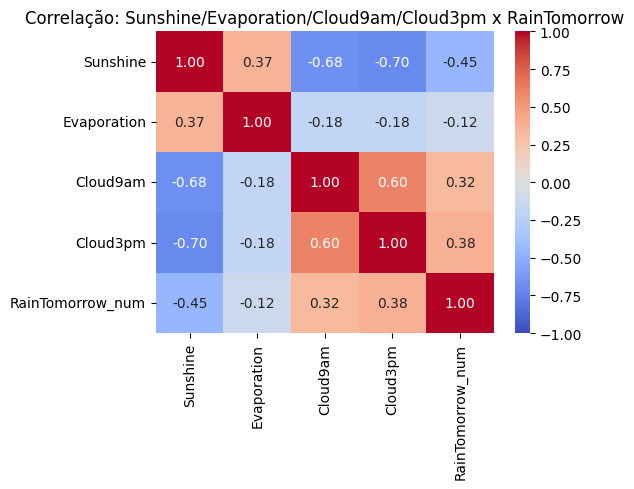

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

df['RainTomorrow_num'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

colunas_interesse = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm', 'RainTomorrow_num']
corr = df[colunas_interesse].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação: Sunshine/Evaporation/Cloud9am/Cloud3pm x RainTomorrow')
plt.tight_layout()
plt.show()

## 3. Qual o tipo de cada coluna?

In [72]:
#3
df.dtypes

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


## 4. Existem colunas que podemos remover?

Podemos analisar em remover as colunas, Sunshine (48%), Evaporation (43%), Cloud3pm (40,8%) e Cloud9am (38,4%) — todas acima de ~35-40% de nulos.

## 5. Os tipos de coluna estão adequados para os tipos de variáveis?

Nem todos. Rodando df.dtypes de novo, dá pra separar em três grupos:

Corretos: as numéricas contínuas (MinTemp, MaxTemp, Rainfall, WindGustSpeed, Humidity9am/3pm, Pressure9am/3pm, Temp9am/3pm etc.) já estão como float64, que é adequado.

Vai precisar de ajuste antes do modelo:

RainToday e RainTomorrow são object com valores "Yes"/"No" — pros modelos (regressão logística, árvore) precisam virar binário (0/1), isso é obrigatório.

In [73]:
# Date -> datetime (antes de extrair Month/Season)
df['Date'] = pd.to_datetime(df['Date'])

# Categóricas de baixa cardinalidade -> category
for col in ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df[col] = df[col].astype('category')

# Alvo e RainToday -> binário 0/1
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(df.dtypes)

Date                datetime64[ns]
Location                  category
MinTemp                    float64
MaxTemp                    float64
Rainfall                   float64
Evaporation                float64
Sunshine                   float64
WindGustDir               category
WindGustSpeed              float64
WindDir9am                category
WindDir3pm                category
WindSpeed9am               float64
WindSpeed3pm               float64
Humidity9am                float64
Humidity3pm                float64
Pressure9am                float64
Pressure3pm                float64
Cloud9am                   float64
Cloud3pm                   float64
Temp9am                    float64
Temp3pm                    float64
RainToday                  float64
RainTomorrow               float64
RainTomorrow_num           float64
dtype: object


## 6. Temos dados duplicados?

In [74]:
df.duplicated().sum()

np.int64(0)

Não temos dados duplicados

## 7. Qual a média, desvio padrão e amplitude das colunas numéricas?

In [75]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,145460,2013-04-04 21:08:51.907053568,2007-11-01 00:00:00,2011-01-11 00:00:00,2013-06-02 00:00:00,2015-06-14 00:00:00,2017-06-25 00:00:00,NaN
MinTemp,143975.0,12.194034,-8.5,7.6,12.0,16.9,33.9,6.398495
MaxTemp,144199.0,23.221348,-4.8,17.9,22.6,28.2,48.1,7.119049
Rainfall,142199.0,2.360918,0.0,0.0,0.0,0.8,371.0,8.47806
Evaporation,82670.0,5.468232,0.0,2.6,4.8,7.4,145.0,4.193704
Sunshine,75625.0,7.611178,0.0,4.8,8.4,10.6,14.5,3.785483
WindGustSpeed,135197.0,40.03523,6.0,31.0,39.0,48.0,135.0,13.607062
WindSpeed9am,143693.0,14.043426,0.0,7.0,13.0,19.0,130.0,8.915375
WindSpeed3pm,142398.0,18.662657,0.0,13.0,19.0,24.0,87.0,8.8098
Humidity9am,142806.0,68.880831,0.0,57.0,70.0,83.0,100.0,19.029164


# 2. Análise Univariada

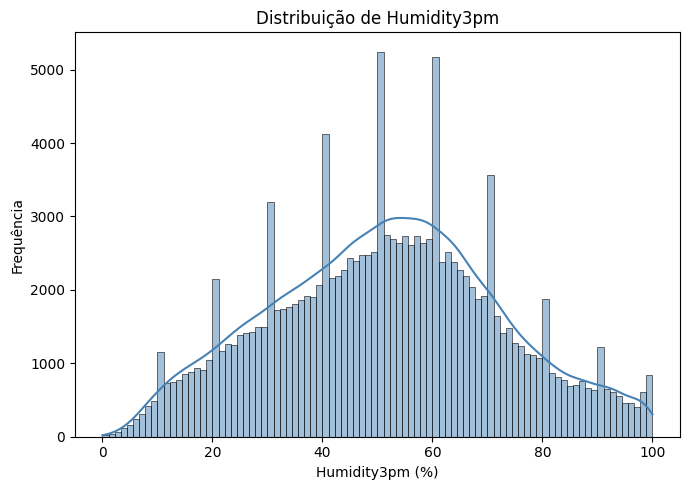

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.histplot(df['Humidity3pm'].dropna(), kde=True, color='steelblue')
plt.title('Distribuição de Humidity3pm')
plt.xlabel('Humidity3pm (%)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

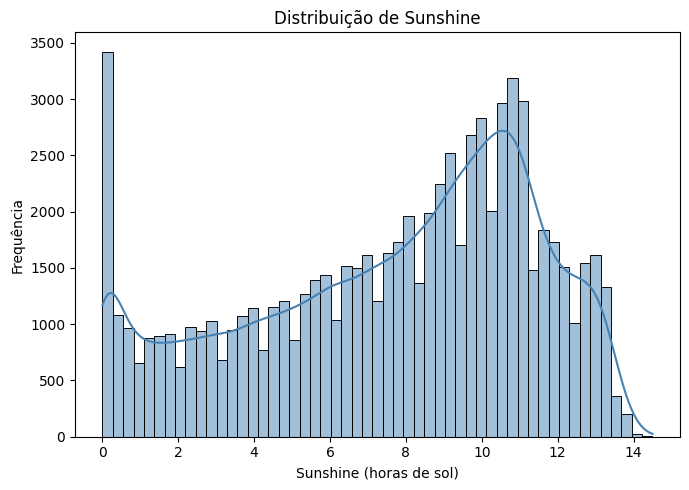

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.histplot(df['Sunshine'].dropna(), kde=True, color='steelblue')
plt.title('Distribuição de Sunshine')
plt.xlabel('Sunshine (horas de sol)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

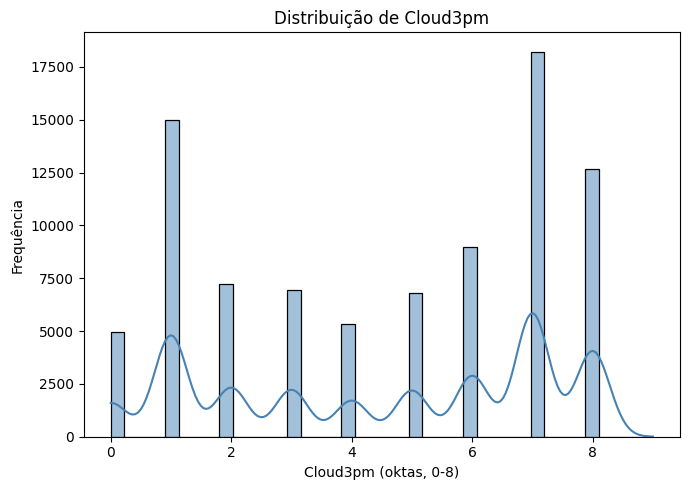

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.histplot(df['Cloud3pm'].dropna(), kde=True, color='steelblue')
plt.title('Distribuição de Cloud3pm')
plt.xlabel('Cloud3pm (oktas, 0-8)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# Análise Bivariada

1. A umidade às 15h (`Humidity3pm`) está associada à chance de chover no dia seguinte?

2. Dias com menos horas de sol (`Sunshine`) tendem a anteceder chuva no dia seguinte?

3. A cobertura de nuvens às 15h (`Cloud3pm`) está relacionada à ocorrência de chuva no dia seguinte?

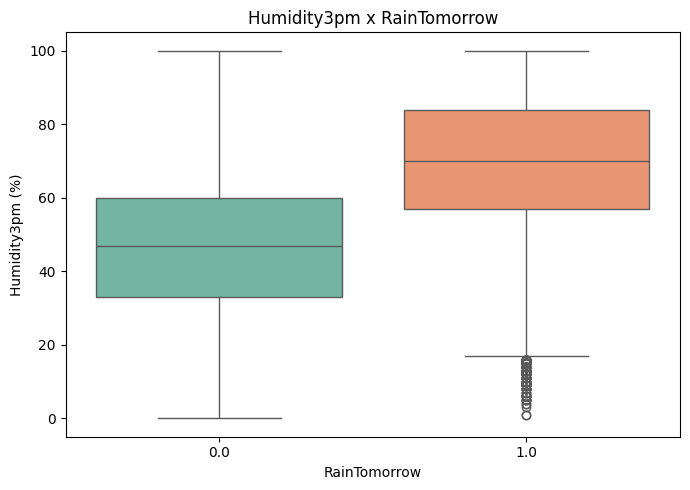

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm', hue='RainTomorrow',
            legend=False, palette='Set2')
plt.title('Humidity3pm x RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Humidity3pm (%)')
plt.tight_layout()
plt.show()

**Humidity3pm** (correlação 0,45): dias que antecedem chuva têm umidade às 15h nitidamente mais alta

In [80]:
df['RainTomorrow_label'] = df['RainTomorrow'].map({0: 'Não', 1: 'Sim'})

In [81]:
amostra = df.sample(n=2000, random_state=42)

<Axes: xlabel='RainTomorrow_label', ylabel='Sunshine'>

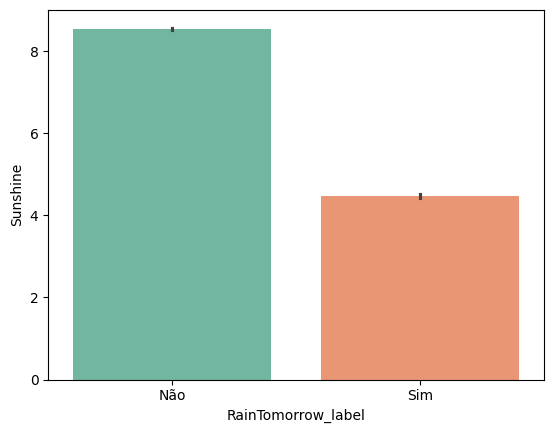

In [82]:
sns.barplot(data=df, x='RainTomorrow_label', y='Sunshine', hue='RainTomorrow_label',
            legend=False, palette='Set2')

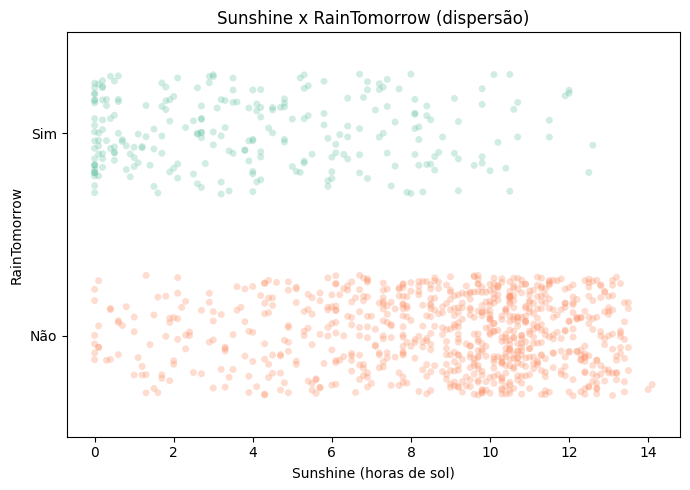

In [83]:
import numpy as np

plt.figure(figsize=(7, 5))
sns.stripplot(data=amostra, x='Sunshine', y='RainTomorrow_label', hue='RainTomorrow_label',
              legend=False, palette='Set2', alpha=0.3, jitter=0.3)
plt.title('Sunshine x RainTomorrow (dispersão)')
plt.xlabel('Sunshine (horas de sol)')
plt.ylabel('RainTomorrow')
plt.tight_layout()
plt.show()

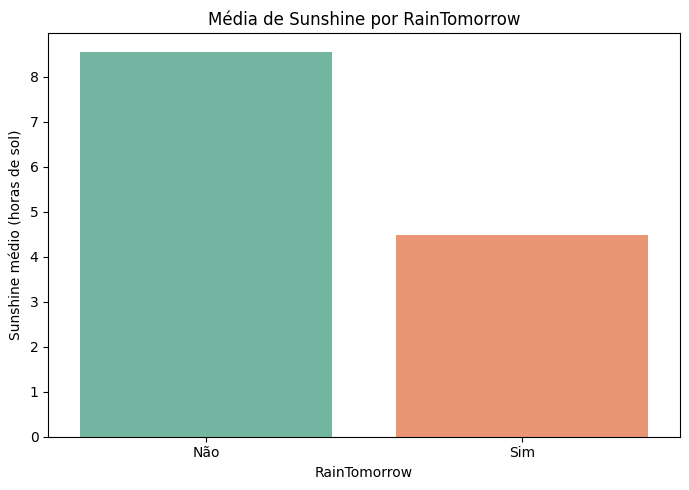

In [84]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df_plot, x='RainTomorrow_label', y='Sunshine', hue='RainTomorrow_label',
            legend=False, palette='Set2')
plt.title('Média de Sunshine por RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Sunshine médio (horas de sol)')
plt.tight_layout()
plt.show()

**Sunshine** (correlação -0,45): relação inversa clara, menos horas de sol no dia tendem a preceder chuva no dia seguinte. Faz sentido meteorologicamente mais nuvens = menos sol = mais chuva.

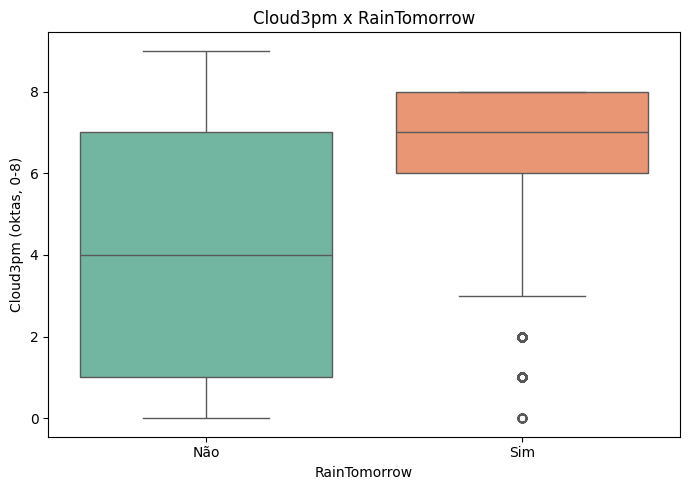

In [85]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='RainTomorrow_label', y='Cloud3pm', hue='RainTomorrow_label',
            legend=False, palette='Set2')
plt.title('Cloud3pm x RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Cloud3pm (oktas, 0-8)')
plt.tight_layout()
plt.show()

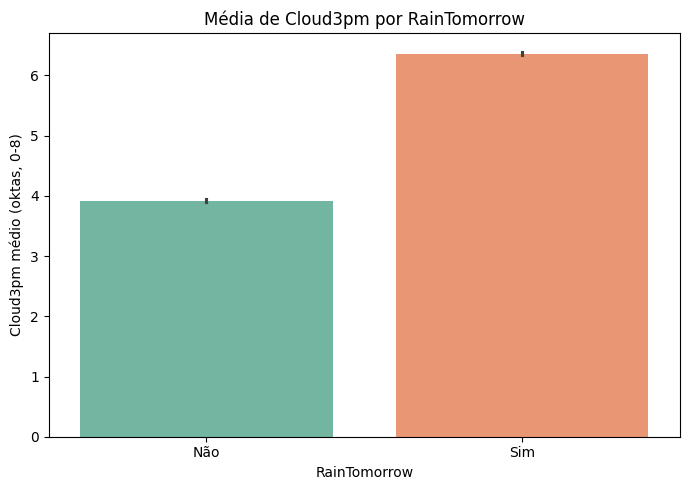

In [86]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='RainTomorrow_label', y='Cloud3pm', hue='RainTomorrow_label',
            legend=False, palette='Set2')
plt.title('Média de Cloud3pm por RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Cloud3pm médio (oktas, 0-8)')
plt.tight_layout()
plt.show()

**Cloud3pm** (correlação 0,38): cobertura de nuvens às 15h também mais alta nos dias que antecedem chuva
(mediana 7 vs 4 oktas), reforçando o padrão da Sunshine.

# **3. Pré-Processamento**

## Featuring - Criando a Coluna Season

In [87]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

def mes_para_estacao(mes):
    if mes in [12, 1, 2]:
        return 'Verao'
    elif mes in [3, 4, 5]:
        return 'Outono'
    elif mes in [6, 7, 8]:
        return 'Inverno'
    else:
        return 'Primavera'

df['Season'] = df['Month'].apply(mes_para_estacao)
df = df.drop(columns=['Date'])

Criamos a Coluna Season porque entendemos que a estação do ano vai influenciar no nosso target RainTomorrow

## Enconding Usando OneHot Enconder

In [88]:
from sklearn.preprocessing import OneHotEncoder

colunas_categoricas = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Season']

encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

encoded_array = encoder.fit_transform(df[colunas_categoricas])

df_encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=df.index
)

df = df.drop(columns=colunas_categoricas)
df = pd.concat([df, df_encoded], axis=1)

print(df.shape)

(145460, 120)


In [89]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 120 columns):
 #    Column                     Dtype  
---   ------                     -----  
 0    MinTemp                    float64
 1    MaxTemp                    float64
 2    Rainfall                   float64
 3    Evaporation                float64
 4    Sunshine                   float64
 5    WindGustSpeed              float64
 6    WindSpeed9am               float64
 7    WindSpeed3pm               float64
 8    Humidity9am                float64
 9    Humidity3pm                float64
 10   Pressure9am                float64
 11   Pressure3pm                float64
 12   Cloud9am                   float64
 13   Cloud3pm                   float64
 14   Temp9am                    float64
 15   Temp3pm                    float64
 16   RainToday                  float64
 17   RainTomorrow               float64
 18   RainTomorrow_num           float64
 19   RainTomorrow_label   

In [90]:
df = df.drop(columns=['RainTomorrow_label', 'RainTomorrow_num'])

Dropamos a 'RainTomorrow_label' que usamos só para plotar os gráficos.

## Excluir os Nulos do Target RainTomorrow

In [91]:
df = df.dropna(subset=['RainTomorrow'])

print(df.shape)
print(df['RainTomorrow'].isnull().sum())

(142193, 118)
0


# **4. Treinamento e Comparação dos Modelos**

In [92]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(113754, 117)
(28439, 117)
(113754,)
(28439,)


In [94]:
X_train_nulos = (X_train.isnull().sum()/X_train.shape[0]).sort_values(ascending=False)*100
X_train_nulos

,0
Sunshine,47.773265
Evaporation,42.807286
Cloud3pm,40.147160
Cloud9am,37.692740
Pressure9am,9.922288
...,...
WindDir3pm_WSW,0.000000
WindDir3pm_nan,0.000000
Season_Outono,0.000000
Season_Primavera,0.000000


Vamos imputar os dados usando mediana simples (SimpleImputer(strategy='median')) pra todas as numéricas.

In [95]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),   # transform, não fit_transform
    columns=X_test.columns,
    index=X_test.index
)

## Balanceamento

Tecnicamente temos um desbalanceamento de 78%/22%
Para esse trabalho vamos usar o class_weight='balanced'que é mais simples, não mexe nos dados, só ajusta o peso da função de perda pra compensar o desbalanceamento.

## Criar os dois Modelos - LogisticRegression e DecisionTree

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

model_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_tree = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [97]:
model_reg.fit(X_train, y_train)
model_tree.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [98]:
previsoes_reg = model_reg.predict(X_test)
previsoes_tree = model_tree.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [100]:
acuracia_reg = accuracy_score(y_test, previsoes_reg)
print(acuracia_reg)
acuracia_tree = accuracy_score(y_test, previsoes_tree)
print(acuracia_tree)

0.7907802665353916
0.77710186715426


In [101]:
print(classification_report(y_test, previsoes_tree))

              precision    recall  f1-score   support

         0.0       0.92      0.78      0.85     22064
         1.0       0.50      0.75      0.60      6375

    accuracy                           0.78     28439
   macro avg       0.71      0.77      0.72     28439
weighted avg       0.82      0.78      0.79     28439



In [102]:
print(classification_report(y_test, previsoes_reg))

              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86     22064
         1.0       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



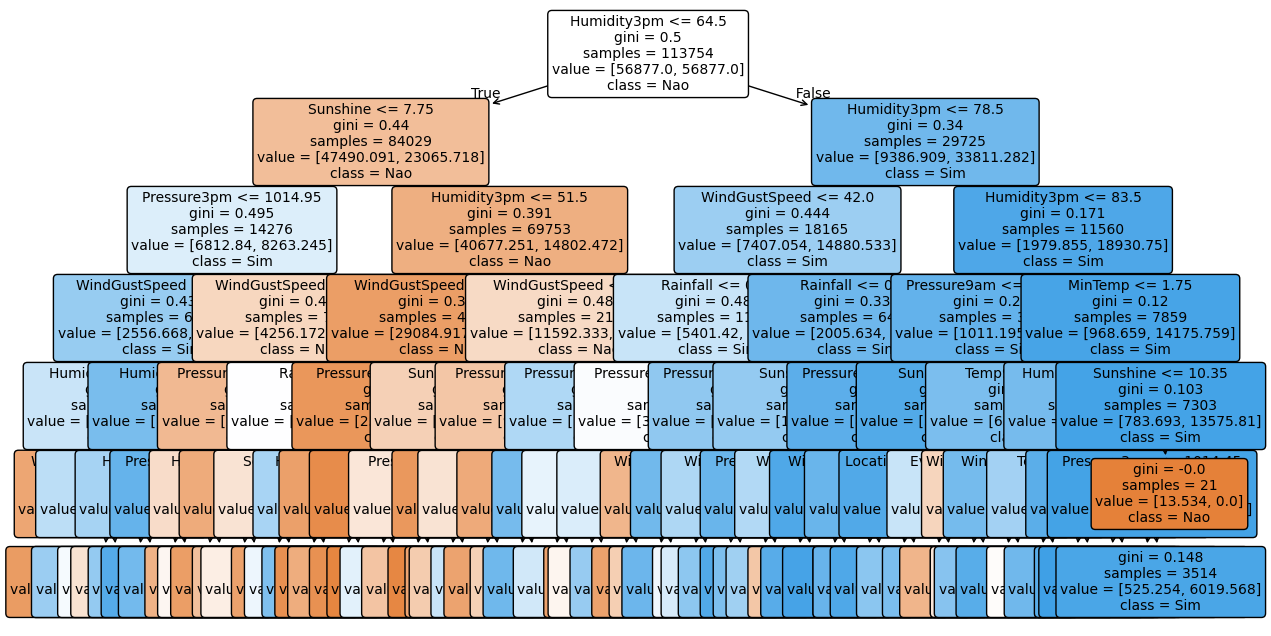

In [103]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(14,8))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names= ['Nao', "Sim"],
    filled = True,
    rounded = True,
    fontsize=10
)

plt.show()

## ROC AUC

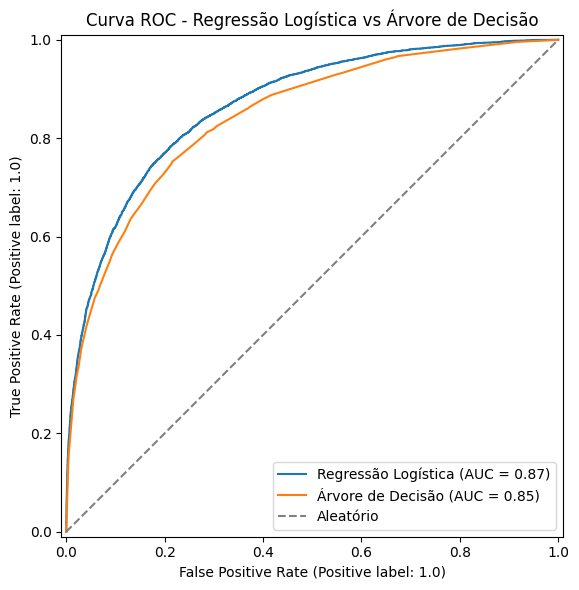

In [104]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_estimator(model_reg, X_test, y_test, name='Regressão Logística', ax=ax)
RocCurveDisplay.from_estimator(model_tree, X_test, y_test, name='Árvore de Decisão', ax=ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
ax.set_title('Curva ROC - Regressão Logística vs Árvore de Decisão')
ax.legend()
plt.tight_layout()
plt.show()

## PR AUC (Precision-Recall)

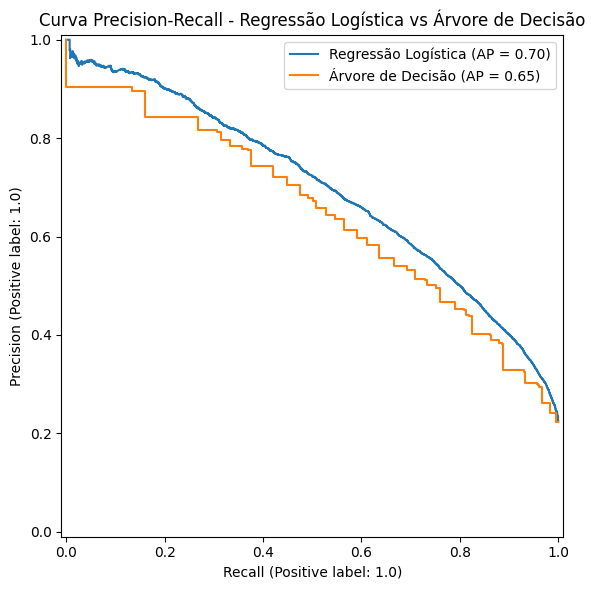

In [105]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_estimator(model_reg, X_test, y_test, name='Regressão Logística', ax=ax)
PrecisionRecallDisplay.from_estimator(model_tree, X_test, y_test, name='Árvore de Decisão', ax=ax)

ax.set_title('Curva Precision-Recall - Regressão Logística vs Árvore de Decisão')
ax.legend()
plt.tight_layout()
plt.show()

## Random Forest

### importando bibliotecas

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [107]:
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

In [109]:
#Precisamos treinar o modelo com nosso dados de treinamento
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [110]:
y_pred_rf = rf.predict(X_test)

In [111]:
y_pred_rf

array([0., 1., 0., ..., 0., 1., 0.])

In [112]:
accuracy = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
class_report = classification_report(y_test, y_pred_rf)

# Exibir resultados
print("Acurácia do modelo:", accuracy)
print("\nMatriz de Confusão:\n", conf_matrix)
print("\nRelatório de Classificação:\n", class_report)

Acurácia do modelo: 0.8567460177924681

Matriz de Confusão:
 [[21166   898]
 [ 3176  3199]]

Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     22064
         1.0       0.78      0.50      0.61      6375

    accuracy                           0.86     28439
   macro avg       0.83      0.73      0.76     28439
weighted avg       0.85      0.86      0.84     28439



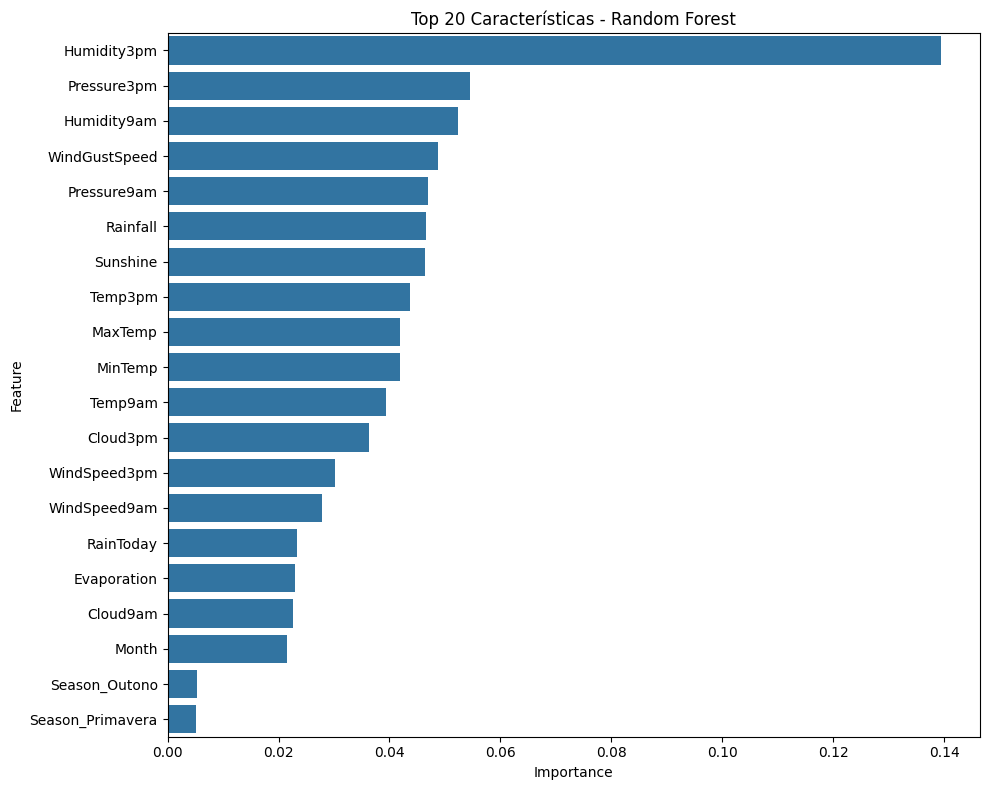

In [115]:
# Obter a importância das características
importances = rf.feature_importances_
feature_names = X_train.columns

# Criar um DataFrame com a importância
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Pegar só as top 20 mais importantes
top_n = 20
importance_top = importance_df.head(top_n)

# Plotar a importância
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_top, x='Importance', y='Feature')
plt.title(f'Top {top_n} Características - Random Forest')
plt.tight_layout()
plt.show()

## XGBOOST

In [114]:
# Criar o modelo XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Fazer previsões
xgb_predictions = xgb_model.predict(X_test)

# Avaliar o modelo
print("Accuracy of XGBoost:", accuracy_score(y_test, xgb_predictions))
print(classification_report(y_test, xgb_predictions))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:10:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of XGBoost: 0.857519603361581
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     22064
         1.0       0.75      0.55      0.63      6375

    accuracy                           0.86     28439
   macro avg       0.81      0.75      0.77     28439
weighted avg       0.85      0.86      0.85     28439



## LightGBM

In [117]:
# Criar o modelo LightGBM
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)

# Fazer previsões
lgb_predictions = lgb_model.predict(X_test)

# Avaliar o modelo
print("Accuracy of LightGBM:", accuracy_score(y_test, lgb_predictions))
print(classification_report(y_test, lgb_predictions))

[LightGBM] [Info] Number of positive: 25502, number of negative: 88252
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2752
[LightGBM] [Info] Number of data points in the train set: 113754, number of used features: 117
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224186 -> initscore=-1.241439
[LightGBM] [Info] Start training from score -1.241439
Accuracy of LightGBM: 0.8578712331657231
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     22064
         1.0       0.76      0.54      0.63      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.74      0.77     28439
weighted avg       0.85      0.86      0.85     28439



## Entre Random Forest, XGBOOST, LightGBM o XGBOOST obteve melhor resultado e vamos melhorar os hiperparâmetros.

In [119]:
  param_grid_xgb = {
    'n_estimators': [50, 100],       # reduzido de 3 para 2 valores
    'max_depth': [3, 6],             # reduzido de 3 para 2 valores
    'learning_rate': [0.1, 0.3],     # reduzido de 3 para 2 valores
    'subsample': [0.8, 1.0],         # reduzido de 3 para 2 valores
    'colsample_bytree': [0.8, 1.0]   # reduzido de 3 para 2 valores
}
# Agora são 2^5 = 32 combinações em vez de 243

grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42),
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("Melhores parâmetros encontrados para XGBoost:", grid_search_xgb.best_params_)
print("Melhor acurácia encontrada para XGBoost:", grid_search_xgb.best_score_)

best_xgb_model = grid_search_xgb.best_estimator_
xgb_gs_predictions = best_xgb_model.predict(X_test)

print("Accuracy of XGBoost after Grid Search:", accuracy_score(y_test, xgb_gs_predictions))
print(classification_report(y_test, xgb_gs_predictions))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Melhores parâmetros encontrados para XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0}
Melhor acurácia encontrada para XGBoost: 0.858079715878123
Accuracy of XGBoost after Grid Search: 0.859770034108091
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     22064
         1.0       0.75      0.56      0.64      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.75      0.78     28439
weighted avg       0.85      0.86      0.85     28439



In [123]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 18.4 MB/s eta 0:00:00


In [124]:
import optuna

In [127]:
def objective_xgb(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 0.1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 0.1),
        'random_state': 42,
        'n_jobs': -1
    }

    # Inicializar e treinar o modelo XGBoost
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)

    # Fazer previsões e calcular a acurácia
    y_pred = model.predict(X_test)
    recall = recall_score(y_test, y_pred)

    return recall

# Criar um estudo Optuna e otimizar para XGBoost
study_xgb = optuna.create_study(direction='maximize') # Queremos maximizar o recall
study_xgb.optimize(objective_xgb, n_trials=25) # Rodar 25 tentativas (pode ajustar este número)

# Imprimir os melhores resultados
print("\nMelhor tentativa (XGBoost com Optuna):")
print(f"  Valor objetivo: {study_xgb.best_value:.4f}")
print("  Melhores hiperparâmetros:")
for key, value in study_xgb.best_params.items():
    print(f"    {key}: {value}")

[I 2026-08-08 19:35:34,562] A new study created in memory with name: no-name-cc43e402-cccb-458a-a936-1dab6da8b98b
[I 2026-08-08 19:35:55,277] Trial 0 finished with value: 0.5874509803921568 and parameters: {'n_estimators': 425, 'learning_rate': 0.1739243273639125, 'max_depth': 10, 'subsample': 0.6449146323131013, 'colsample_bytree': 0.7365543888750996, 'gamma': 0.2880893471673175, 'reg_alpha': 0.03971560617723305, 'reg_lambda': 0.004716359035817392}. Best is trial 0 with value: 0.5874509803921568.
[I 2026-08-08 19:36:06,186] Trial 1 finished with value: 0.5750588235294117 and parameters: {'n_estimators': 444, 'learning_rate': 0.24189611289382856, 'max_depth': 10, 'subsample': 0.9102991771012358, 'colsample_bytree': 0.6674177365591528, 'gamma': 0.4775273806077598, 'reg_alpha': 0.09755685556770981, 'reg_lambda': 0.05068891495167766}. Best is trial 0 with value: 0.5874509803921568.
[I 2026-08-08 19:36:13,592] Trial 2 finished with value: 0.5372549019607843 and parameters: {'n_estimators':


Melhor tentativa (XGBoost com Optuna):
  Valor objetivo: 0.5878
  Melhores hiperparâmetros:
    n_estimators: 408
    learning_rate: 0.29518386581879624
    max_depth: 8
    subsample: 0.6025499207282452
    colsample_bytree: 0.7093783674708055
    gamma: 0.4035695990886548
    reg_alpha: 0.07523297286635136
    reg_lambda: 0.07586797815394879


In [129]:
# Opcional: Treinar o modelo final XGBoost com os melhores hiperparâmetros
best_xgb_model_optuna = xgb.XGBClassifier(**study_xgb.best_params)
best_xgb_model_optuna.fit(X_train, y_train)

y_pred_xgb_optuna = best_xgb_model_optuna.predict(X_test)
optuna_xgb_recall = recall_score(y_test, y_pred_xgb_optuna)
print(f"\nRecall do XGBoost com Optuna (melhores parâmetros): {optuna_xgb_recall:.4f}")
print("Relatório de Classificação do XGBoost com Optuna:\n", classification_report(y_test, y_pred_xgb_optuna))


Recall do XGBoost com Optuna (melhores parâmetros): 0.5823
Relatório de Classificação do XGBoost com Optuna:
               precision    recall  f1-score   support

         0.0       0.89      0.93      0.91     22064
         1.0       0.71      0.58      0.64      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.76      0.77     28439
weighted avg       0.85      0.85      0.85     28439

